# Figure 3 — SLDA vs DLBT Schematic (portrait, one-page)

Each cell draws one visual element. Run all cells top-to-bottom, then the final assembly cell exports the SVG/PDF.

**All macro-knobs live in Cell 0 (`CFG`)** — canvas size, column geometry, per-row layout, colours, fonts. Tune there without touching drawing logic.

In [14]:
# ═════════════════════════════════════════════════════════════════
# Cell 0 — Global config / macro-knobs
# ═════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Polygon as MplPoly, FancyArrowPatch
from scipy.special import gammaln

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica Neue', 'Arial', 'DejaVu Sans']

CFG = dict(
    # ── canvas (portrait, one page) ──────────────────────────────
    fig_w = 12.0,
    fig_h = 16.0,

    # ── overall layout (figure-fraction) ─────────────────────────
    top_strip = 0.155,   # header: titles + stimulus + CLIP box + branch arrows
    bot_strip = 0.040,   # P̂(yes|t,x) row
    col_gap   = 0.03,    # gap between the two panel boxes
    side_pad  = 0.015,   # outer margin left/right of the boxes
    box_pad   = 0.010,   # inner margin inside each box (per sub-axes)

    # ── panel-box border ─────────────────────────────────────────
    slda_color   = '#6a3d9a',   # purple
    dlbt_color   = '#cb2027',   # red
    box_lw       = 2.4,
    box_rounding = 0.018,

    # ── module-box (trapezoid) styling ───────────────────────────
    mod_top_w   = 0.92,   # trapezoid top-edge width  (frac of allocated ax)
    mod_bot_w   = 0.54,   # trapezoid bottom-edge width
    mod_lw      = 2.0,
    mod_fill_a  = '14',   # hex alpha appended to edge colour for fill
    mod_title_c = '#222222',
    mod_sub_c   = '#888888',

    # ── per-task styling ─────────────────────────────────────────
    task_colors = ['#1b9e77', '#d95f02', '#7570b3'],
    task_edges  = ['#147b5c', '#b34d01', '#5a548f'],
    task_names  = ['Task 1', 'Task 2', 'Task T'],
    task_k      = [0.8, 2.5, 1.4],

    # ── font sizes ───────────────────────────────────────────────
    fs_coltitle = 15,   # SLDA / DLBT column titles
    fs_modtitle = 12,   # module-box bold title
    fs_modsub   = 10,   # module-box grey status line
    fs_cloudlbl = 11,   # axes labels d_1..d_1024 / z_1..z_K
    fs_caption  = 11,   # descriptive captions
    fs_task     = 10,   # per-task panel title
    fs_eq       = 10,   # σ(·) equation
    fs_phat     = 10,   # P̂(yes|t,x)
    fs_stim     = 11,   # stimulus label

    # ── point-cloud ──────────────────────────────────────────────
    cloud_seed  = 13,
    cloud_n     = 600,
    cloud_s     = 13,
    cloud_alpha = 0.18,
    cloud_color = '0.35',
    stim_circle = '#00b0b9',   # teal 'this-stimulus' ring

    # ── dirichlet surface ────────────────────────────────────────
    dir_alpha    = np.array([4.0, 4.0, 3.0]),
    dir_n_strips = 160,
    dir_n_sub    = 100,
    dir_d_scale  = 0.95,
    dir_cmap     = 'YlOrRd',
    dir_plane_c  = '#4CAF50',
    dir_plane_a  = 0.24,
    dir_z2c      = 0.38,

    # ── connector arrows ─────────────────────────────────────────
    arr_lw = 1.4,
    arr_ms = 12,
)

# ── Per-row vertical layout inside each column box ───────────────
# Coordinates are fractions of the INNER column height (0 = box bottom,
# 1 = box top). Each entry is (top, height). Tweak freely.
ROWS_SLDA = dict(
    attpool = (0.995, 0.060),
    cloud   = (0.900, 0.255),
    caption = (0.615, 0.050),
    panels  = (0.530, 0.215),
    eqs     = (0.285, 0.035),
    sigmoid = (0.225, 0.160),
)
ROWS_DLBT = dict(
    attpool = (0.995, 0.060),
    cloud   = (0.900, 0.255),
    mapper  = (0.590, 0.060),
    surface = (0.500, 0.430),
)

SLDA_C = CFG['slda_color']
DLBT_C = CFG['dlbt_color']
print('Config loaded.')

Config loaded.


In [15]:
# ═════════════════════════════════════════════════════════════════
# Cell 1 — Shared helpers
# ═════════════════════════════════════════════════════════════════

def arrow(ax, start, end, color='black', lw=None, ms=None, zorder=10,
          style='->', rad=0.0, shrinkA=1, shrinkB=1, coords='data'):
    """Arrow from start→end. coords='data' or 'axes fraction'."""
    lw = lw if lw is not None else CFG['arr_lw']
    ms = ms if ms is not None else CFG['arr_ms']
    ax.annotate('', xy=end, xytext=start,
                xycoords=coords, textcoords=coords,
                arrowprops=dict(arrowstyle=style, lw=lw, color=color,
                                connectionstyle=f'arc3,rad={rad}',
                                shrinkA=shrinkA, shrinkB=shrinkB,
                                mutation_scale=ms),
                zorder=zorder)


def draw_cloud(ax, rng=None, n=None, s=None, alpha=None, color=None):
    rng   = rng   or np.random.default_rng(CFG['cloud_seed'])
    n     = n     or CFG['cloud_n']
    s     = s     if s is not None else CFG['cloud_s']
    alpha = alpha if alpha is not None else CFG['cloud_alpha']
    color = color or CFG['cloud_color']
    X = rng.multivariate_normal(np.array([0.72, 0.95]),
                                np.array([[0.55, 0.16], [0.16, 0.40]]), size=n)
    ax.scatter(X[:, 0], X[:, 1], s=s, color=color, alpha=alpha,
               linewidths=0, zorder=3)
    return X


_ORIGIN = np.array([0.0, 0.0])
_AXES_CLOUD = [
    (np.array([ 0.00,  3.15]), r'$d_1$',     ( 0.00,  0.28)),
    (np.array([ 3.35,  0.00]), r'$d_2$',     ( 0.28,  0.02)),
    (np.array([ 2.45, -0.55]), r'$d_3$',     ( 0.28, -0.03)),
    (np.array([ 1.75, -0.95]), r'$d_4$',     ( 0.22, -0.14)),
    (np.array([-0.90, -1.30]), r'$d_{1024}$',(-0.40, -0.18)),
]

def draw_cloud_axes(ax, fs=None):
    fs = fs or CFG['fs_cloudlbl']
    for end, label, off in _AXES_CLOUD:
        arrow(ax, _ORIGIN, end, lw=1.15, ms=8, zorder=10)
        ax.text(end[0]+off[0], end[1]+off[1], label,
                fontsize=fs, ha='center', va='center', zorder=11)
    ax.scatter([0.18, 0.38, 0.58], [-1.42]*3, s=5, color='black', zorder=11)


def cloud_ax_style(ax):
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_xlim(-2.55, 4.05)
    ax.set_ylim(-1.85, 3.65)


print('Helpers loaded.')

Helpers loaded.


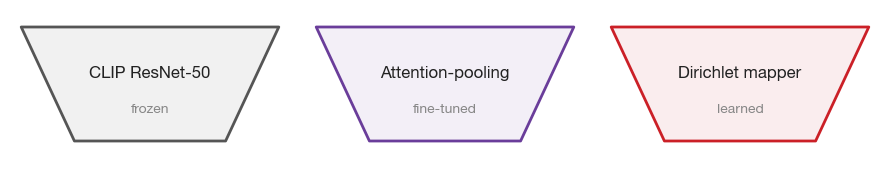

In [16]:
# ═════════════════════════════════════════════════════════════════
# Cell 2 — Element: trapezoid module box (Attpool / Mapper / CLIP)
# ═════════════════════════════════════════════════════════════════

def draw_module_box(ax, title, subtitle=None, edge='black',
                    top_w=None, bot_w=None, lw=None,
                    fs_title=None, fs_sub=None, flip=False):
    """
    Draw a downward-funnel trapezoid module block filling `ax`.
      title    : bold module name (e.g. 'Attention-pooling')
      subtitle : grey status line (e.g. 'fine-tuned')
      edge     : outline colour (usually the column colour)
      flip     : if True, widen at the bottom instead of the top
    The ax is used purely as a drawing canvas (axes-fraction coords).
    """
    top_w    = top_w    if top_w    is not None else CFG['mod_top_w']
    bot_w    = bot_w    if bot_w    is not None else CFG['mod_bot_w']
    lw       = lw       if lw       is not None else CFG['mod_lw']
    fs_title = fs_title or CFG['fs_modtitle']
    fs_sub   = fs_sub   or CFG['fs_modsub']

    ax.axis('off')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    tw, bw = (bot_w, top_w) if flip else (top_w, bot_w)
    yb, yt = 0.12, 0.88
    pts = [(0.5 - bw/2, yb), (0.5 + bw/2, yb),
           (0.5 + tw/2, yt), (0.5 - tw/2, yt)]
    fill = edge + CFG['mod_fill_a']
    ax.add_patch(MplPoly(pts, closed=True, facecolor=fill, edgecolor=edge,
                         linewidth=lw, joinstyle='round', zorder=2))

    if subtitle:
        ax.text(0.5, 0.575, title, ha='center', va='center',
                fontsize=fs_title, fontweight='bold',
                color=CFG['mod_title_c'], zorder=3)
        ax.text(0.5, 0.335, subtitle, ha='center', va='center',
                fontsize=fs_sub, style='italic',
                color=CFG['mod_sub_c'], zorder=3)
    else:
        ax.text(0.5, 0.5, title, ha='center', va='center',
                fontsize=fs_title, fontweight='bold',
                color=CFG['mod_title_c'], zorder=3)


# ── preview ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(9, 1.8))
draw_module_box(axes[0], 'CLIP ResNet-50', 'frozen',      edge='#555555')
draw_module_box(axes[1], 'Attention-pooling', 'fine-tuned', edge=SLDA_C)
draw_module_box(axes[2], 'Dirichlet mapper', 'learned',    edge=DLBT_C)
plt.tight_layout(); plt.show(); plt.close()

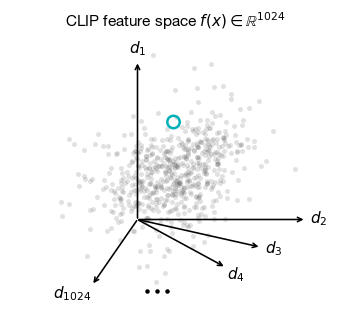

In [17]:
# ═════════════════════════════════════════════════════════════════
# Cell 3 — Element: CLIP latent-space point cloud
# ═════════════════════════════════════════════════════════════════

def draw_latent_space(ax, rng=None, title=None, title_fs=None, annotation=None):
    rng = rng or np.random.default_rng(CFG['cloud_seed'])
    cloud_ax_style(ax)
    draw_cloud(ax, rng=rng)
    draw_cloud_axes(ax)
    if title:
        ax.text(0.5, 1.02, title, transform=ax.transAxes,
                ha='center', va='bottom',
                fontsize=title_fs or CFG['fs_caption'], fontweight='bold')
    if annotation:
        ax.scatter([annotation[0]], [annotation[1]], s=80, facecolors='none',
                   edgecolors=CFG['stim_circle'], linewidths=1.8, zorder=12)


# ── preview ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3.6, 3.4))
draw_latent_space(ax, title=r'CLIP feature space $f(x)\in\mathbb{R}^{1024}$',
                  annotation=(0.72, 1.95))
plt.tight_layout(); plt.show(); plt.close()

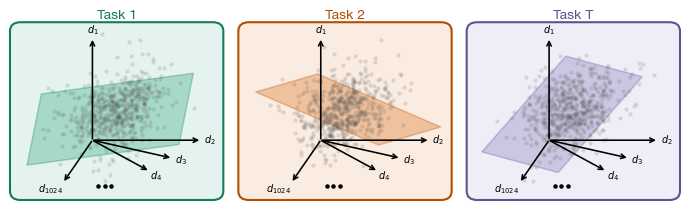

In [18]:
# ═════════════════════════════════════════════════════════════════
# Cell 4 — Element: per-task hyperplane panel
# ═════════════════════════════════════════════════════════════════

def _make_plane(center, u, v):
    c, u, v = np.array(center), np.array(u), np.array(v)
    return np.array([c-u-v, c+u-v, c+u+v, c-u+v])

_PLANES = {
    'Task 1': _make_plane((0.55, 0.65), ( 2.35,  0.32), ( 0.22,  1.10)),
    'Task 2': _make_plane((0.85, 0.95), ( 1.90, -0.82), ( 0.96,  0.28)),
    'Task T': _make_plane((0.40, 0.80), ( 1.30,  1.48), (-1.18,  0.32)),
}

def draw_task_panel(ax, name, color, edge, rng=None, plane_alpha=0.30):
    rng = rng or np.random.default_rng(CFG['cloud_seed'])
    cloud_ax_style(ax)
    draw_cloud(ax, rng=rng, s=CFG['cloud_s']-4, alpha=CFG['cloud_alpha'])
    ax.add_patch(MplPoly(_PLANES[name], closed=True, facecolor=color,
                         edgecolor=edge, alpha=plane_alpha, linewidth=1.1,
                         joinstyle='round', zorder=2))
    draw_cloud_axes(ax, fs=max(CFG['fs_cloudlbl']-4, 6))
    ax.set_facecolor('none')
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.add_patch(FancyBboxPatch((0, 0), 1, 1,
                 boxstyle='round,pad=0,rounding_size=0.05',
                 transform=ax.transAxes, facecolor=color+'1e',
                 edgecolor=edge, linewidth=1.5, clip_on=False, zorder=0))
    ax.set_title(name, color=edge, fontsize=CFG['fs_task'],
                 fontweight='bold', pad=3)


# ── preview ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(7, 2.6))
rng = np.random.default_rng(CFG['cloud_seed'])
for ax, n, c, e in zip(axes, CFG['task_names'], CFG['task_colors'], CFG['task_edges']):
    draw_task_panel(ax, n, c, e, rng=rng)
plt.tight_layout(); plt.show(); plt.close()

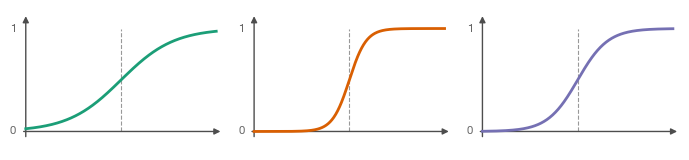

In [19]:
# ═════════════════════════════════════════════════════════════════
# Cell 5 — Element: logistic sigmoid curve (clean L-axes)
# ═════════════════════════════════════════════════════════════════

def draw_sigmoid(ax, color, k=1.0, xlim=(-4.5, 4.5), lw=2.0):
    ax.axis('off')
    ax.set_xlim(xlim[0]-0.6, xlim[1]+0.3)
    ax.set_ylim(-0.18, 1.18)

    z = np.linspace(*xlim, 400)
    p = 1.0 / (1.0 + np.exp(-k * z))
    ax.plot(z, p, color=color, lw=lw, zorder=4)
    ax.plot([0, 0], [0, 1], color='0.6', lw=0.8, ls='--', zorder=2)

    x0 = xlim[0]                      # left axis position (data x)
    arrow(ax, (x0, -0.05), (x0, 1.12), color='0.30', lw=1.0, ms=9,
          style='-|>', shrinkA=0, shrinkB=0, zorder=3)   # y-axis
    arrow(ax, (x0-0.1, 0.0), (xlim[1]+0.2, 0.0), color='0.30', lw=1.0, ms=9,
          style='-|>', shrinkA=0, shrinkB=0, zorder=3)   # x-axis
    ax.text(x0-0.45, 1.0, '1', ha='right', va='center', fontsize=8, color='0.4')
    ax.text(x0-0.45, 0.0, '0', ha='right', va='center', fontsize=8, color='0.4')


# ── preview ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(7, 1.7))
for ax, c, k in zip(axes, CFG['task_colors'], CFG['task_k']):
    draw_sigmoid(ax, color=c, k=k)
plt.tight_layout(); plt.show(); plt.close()

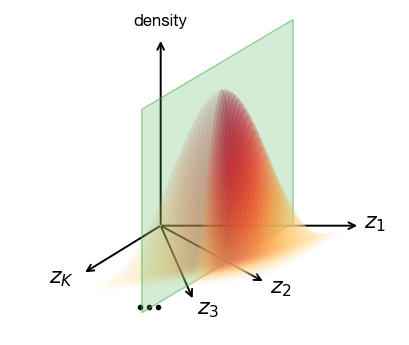

In [20]:
# ═════════════════════════════════════════════════════════════════
# Cell 6 — Element: Dirichlet surface (+ decision-cut plane)
# ═════════════════════════════════════════════════════════════════

def _logpdf(bary, alpha):
    log_B = np.sum(gammaln(alpha)) - gammaln(alpha.sum())
    return np.sum((alpha-1.0)*np.log(np.clip(bary, 1e-300, None)), axis=1) - log_B

def _soften(rgba, mix=(1,1,1), amount=0.0):
    rgb = np.array(rgba[:3])
    return (*((1-amount)*rgb + amount*np.array(mix)), rgba[3])

_DIR_PROJ = dict(
    e_dens=np.array([0.00, 3.15]), e_z1=np.array([3.35, 0.00]),
    e_z2=np.array([-1.80,-1.20]),  e_z3=np.array([1.75,-0.95]))
_DIR_AXES = [
    ('e_dens', 'density', ( 0.00, 0.30), 12, True ),
    ('e_z1',  r'$z_1$',  ( 0.28, 0.02), 16, False),
    ('e_z3',  r'$z_2$',  ( 0.28,-0.12), 16, False),
    (None,    r'$z_3$',  ( 0.25,-0.18), 16, False),
    (None,    r'$z_K$',  (-0.38,-0.10), 16, False),
]
_DIR_FIXED = {r'$z_3$': np.array([0.55,-1.25]), r'$z_K$': np.array([-1.30,-0.80])}

def draw_dirichlet(ax, alpha=None, n_strips=None, n_sub=None, d_scale=None,
                   cmap=None, show_plane=True, plane_color=None,
                   plane_alpha=None, z2c=None, plane_label=None):
    alpha       = alpha       if alpha       is not None else CFG['dir_alpha']
    n_strips    = n_strips    or CFG['dir_n_strips']
    n_sub       = n_sub       or CFG['dir_n_sub']
    d_scale     = d_scale     or CFG['dir_d_scale']
    cmap        = cmap        or CFG['dir_cmap']
    plane_color = plane_color or CFG['dir_plane_c']
    plane_alpha = plane_alpha if plane_alpha is not None else CFG['dir_plane_a']
    z2c         = z2c         or CFG['dir_z2c']

    e_dens, e_z1, e_z2, e_z3 = (_DIR_PROJ[k] for k in ('e_dens','e_z1','e_z2','e_z3'))

    tg = np.linspace(0.005, 0.995, 80); g1, g2 = np.meshgrid(tg, tg)
    ok = (g1+g2) <= 0.995
    lpdf_max = _logpdf(np.column_stack([g1[ok], g2[ok], 1-g1[ok]-g2[ok]]), alpha).max()
    cmap_fn = plt.get_cmap(cmap)
    origin = np.array([0.0, 0.0])

    ax.set_aspect('equal'); ax.axis('off')
    for key, label, off, fs, italic in _DIR_AXES:
        end = _DIR_PROJ[key] if key else _DIR_FIXED[label]
        arrow(ax, origin, end, lw=1.4, ms=12, zorder=1)
        ax.text(end[0]+off[0], end[1]+off[1], label, fontsize=fs,
                ha='center', va='center', zorder=1,
                style='italic' if italic else 'normal')
    ax.scatter([-0.05,-0.20,-0.35], [-1.38]*3, s=9, color='black', zorder=1)

    z2_vals = np.linspace(0.005, 0.975, n_strips)
    strips = []
    for z2v in sorted(z2_vals, reverse=True):
        z1_max = 1.0 - z2v - 0.005
        if z1_max < 0.02:
            continue
        z1 = np.linspace(0.005, z1_max, n_sub+1); z3 = 1.0 - z1 - z2v
        pdf = np.exp(_logpdf(np.column_stack([z1, np.full_like(z1, z2v), z3]), alpha) - lpdf_max)
        dv = pdf * d_scale
        sx_f = z1*e_z1[0] + z2v*e_z2[0] + z3*e_z3[0]
        sy_f = z1*e_z1[1] + z2v*e_z2[1] + z3*e_z3[1]
        strips.append((z2v, pdf, sx_f, sy_f, sx_f+dv*e_dens[0], sy_f+dv*e_dens[1]))

    for z2v, pdf, sx_f, sy_f, sx, sy in strips:
        front = z2v < z2c
        for k in range(n_sub):
            c = cmap_fn(0.5*(pdf[k]+pdf[k+1]))
            if front: c = _soften(c, (1,.45,.45), 0.12); a = 0.12
            else:     c = _soften(c, (1,1,1), 0.18);     a = 0.085
            ax.add_patch(MplPoly(list(zip([sx[k],sx[k+1],sx_f[k+1],sx_f[k]],
                                          [sy[k],sy[k+1],sy_f[k+1],sy_f[k]])),
                         facecolor=c, edgecolor='none', lw=0, alpha=a, zorder=2))

    if show_plane:
        def _fp(z1v):
            z3v = 1-z1v-z2c
            return np.array([z1v*e_z1[0]+z2c*e_z2[0]+z3v*e_z3[0],
                              z1v*e_z1[1]+z2c*e_z2[1]+z3v*e_z3[1]])
        p_bl, p_br = _fp(-0.45), _fp(1.15)
        h = d_scale*e_dens*1.15
        pts = [p_bl, p_br, p_br+h, p_bl+h]
        ax.add_patch(MplPoly(pts, facecolor=plane_color, edgecolor='none',
                             alpha=plane_alpha, zorder=3))
        ax.add_patch(MplPoly(pts, facecolor='none', edgecolor=plane_color,
                             linewidth=1.0, alpha=0.55, zorder=3.1))
        if plane_label:
            ax.text(*(p_br+h*0.9), plane_label, fontsize=10, color=plane_color,
                    fontweight='bold', ha='left', va='bottom', zorder=6)

    for z2v, pdf, sx_f, sy_f, sx, sy in strips:
        if z2v >= z2c:
            continue
        for k in range(n_sub):
            c = _soften(cmap_fn(0.5*(pdf[k]+pdf[k+1])), (1,.35,.35), 0.10)
            ax.add_patch(MplPoly(list(zip([sx[k],sx[k+1],sx_f[k+1],sx_f[k]],
                                          [sy[k],sy[k+1],sy_f[k+1],sy_f[k]])),
                         facecolor=c, edgecolor='none', lw=0, alpha=0.14, zorder=4))

    ax.set_xlim(-2.55, 4.05); ax.set_ylim(-1.85, 3.65)


# ── preview (fast/low-res) ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.2, 3.9))
draw_dirichlet(ax, n_strips=80, n_sub=60)
plt.tight_layout(); plt.show(); plt.close()

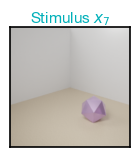

In [21]:
# ═════════════════════════════════════════════════════════════════
# Cell 7 — Element: stimulus thumbnail
# ═════════════════════════════════════════════════════════════════
from pathlib import Path

STIM_IMG_PATH = Path('../stimuli/imgs/prototype_imgs') / \
    '000457_shico_f04_yaw016_s043_lab069-+040--038_t008_gl081_xy+0149-+0017_random.png'
STIM_LABEL = r'Stimulus $x_7$'

def draw_stimulus(ax, img_path=None, label=None, label_color=None,
                  border_color='black', border_lw=1.2):
    img_path    = Path(img_path or STIM_IMG_PATH)
    label       = label       or STIM_LABEL
    label_color = label_color or CFG['stim_circle']
    ax.axis('off')
    if img_path.exists():
        ax.imshow(plt.imread(str(img_path)))
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_edgecolor(border_color); sp.set_linewidth(border_lw)
        ax.set_xticks([]); ax.set_yticks([]); ax.axis('on')
    else:
        ax.add_patch(mpatches.FancyBboxPatch((0.08, 0.08), 0.84, 0.84,
                     boxstyle='round,pad=0.02', facecolor='#dddddd',
                     edgecolor=border_color, lw=border_lw, transform=ax.transAxes))
        ax.text(0.5, 0.5, '?', transform=ax.transAxes, ha='center', va='center',
                fontsize=16, color='0.5')
    ax.set_title(label, color=label_color, fontsize=CFG['fs_stim'],
                 fontweight='bold', pad=3)


# ── preview ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(1.5, 1.7))
draw_stimulus(ax)
plt.tight_layout(); plt.show(); plt.close()

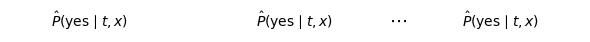

In [22]:
# ═════════════════════════════════════════════════════════════════
# Cell 8 — Element: P̂(yes | t, x) output row
# ═════════════════════════════════════════════════════════════════

def draw_phat_row(ax, n_tasks=3, dots=True, fs=None):
    fs = fs or CFG['fs_phat']
    ax.axis('off'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    xs = np.linspace(0.14, 0.86, n_tasks)
    label = r'$\hat{P}(\mathrm{yes}\mid t, x)$'
    for x in xs:
        ax.text(x, 0.5, label, ha='center', va='center', fontsize=fs)
    if dots and n_tasks >= 3:
        ax.text((xs[-2]+xs[-1])/2, 0.5, r'$\cdots$', ha='center', va='center', fontsize=fs+3)


# ── preview ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 0.5))
draw_phat_row(ax)
plt.tight_layout(); plt.show(); plt.close()

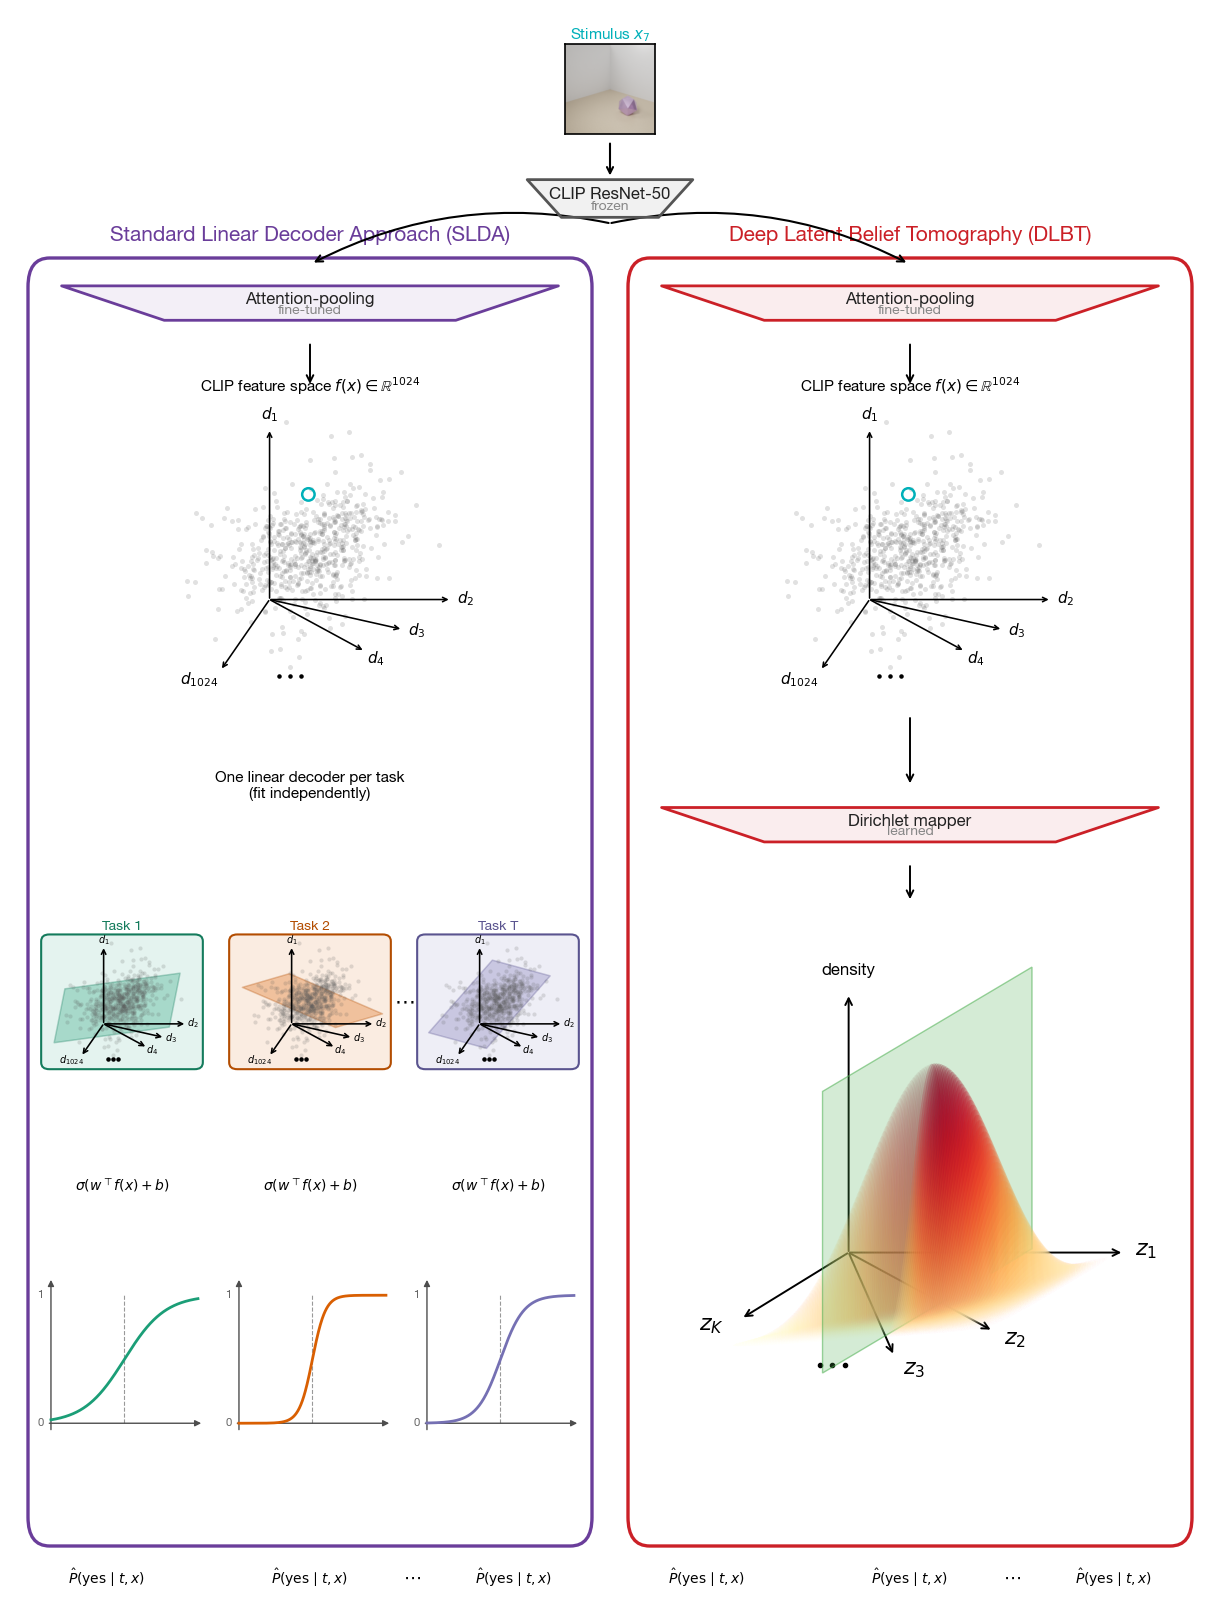

Saved → figure3_schematic.svg  and  figure3_schematic.pdf


In [23]:
# ═════════════════════════════════════════════════════════════════
# Cell 9 — Full-figure assembly  →  figure3_schematic.svg / .pdf
# ═════════════════════════════════════════════════════════════════
FW, FH = CFG['fig_w'], CFG['fig_h']
TOP, BOT = CFG['top_strip'], CFG['bot_strip']
GAP, SIDE, PAD = CFG['col_gap'], CFG['side_pad'], CFG['box_pad']
INNER_H = 1.0 - TOP - BOT

# Column boundaries (figure-fraction)
left_L  = SIDE
right_L = 0.5 - GAP/2
col_w   = right_L - left_L
left_R  = 0.5 + GAP/2
right_R = 1.0 - SIDE
col_wR  = right_R - left_R

fig = plt.figure(figsize=(FW, FH))
fig.patch.set_facecolor('white')

def A(l, b, w, h):
    return fig.add_axes([l, b, w, h])

def row_rect(col_left, col_w, top, height, pad=PAD):
    """(left,bottom,width,height) for a row given INNER-fraction top & height."""
    l = col_left + pad
    w = col_w - 2*pad
    b = BOT + INNER_H*(top - height) + pad
    h = INNER_H*height - 2*pad
    return l, b, w, h

def row_cy(top, height):
    """figure-fraction y of a row's vertical centre."""
    return BOT + INNER_H*(top - height/2)

# ── background axes (boxes, titles, all connector arrows) ────────
bg = A(0, 0, 1, 1); bg.set_xlim(0, 1); bg.set_ylim(0, 1); bg.axis('off')
bg.set_zorder(-10)

for bx, bw, bc in [(left_L, col_w, SLDA_C), (left_R, col_wR, DLBT_C)]:
    bg.add_patch(FancyBboxPatch((bx, BOT), bw, INNER_H,
                 boxstyle=f'round,pad=0,rounding_size={CFG["box_rounding"]}',
                 facecolor='none', edgecolor=bc, linewidth=CFG['box_lw'],
                 transform=bg.transAxes, clip_on=False, zorder=1))

# Column titles
for x, label, color in [
    (left_L + col_w*0.5,  'Standard Linear Decoder Approach (SLDA)', SLDA_C),
    (left_R + col_wR*0.5, 'Deep Latent Belief Tomography (DLBT)',    DLBT_C)]:
    bg.text(x, BOT + INNER_H + 0.008, label, ha='center', va='bottom',
            color=color, fontsize=CFG['fs_coltitle'], fontweight='bold')

# ── header: stimulus → CLIP box → branch arrows ──────────────────
stim_w = 0.075
stim_b = 1 - TOP*0.52
ax_stim = A(0.5 - stim_w/2, stim_b, stim_w, TOP*0.40)
draw_stimulus(ax_stim)

clip_w, clip_h = 0.15, TOP*0.20
clip_b = 1 - TOP*0.86
ax_clip = A(0.5 - clip_w/2, clip_b, clip_w, clip_h)
draw_module_box(ax_clip, 'CLIP ResNet-50', 'frozen', edge='#555555')

# arrow: stimulus → CLIP box
arrow(bg, (0.5, stim_b - 0.002), (0.5, clip_b + clip_h - 0.002),
      coords='axes fraction', lw=1.5, ms=11, zorder=5)

# two curved branch arrows: CLIP box → each Attpool box
att_top_cy = row_cy(*ROWS_SLDA['attpool'])
for col_cx, rad in [(left_L + col_w*0.5, 0.18), (left_R + col_wR*0.5, -0.18)]:
    arrow(bg, (0.5, clip_b), (col_cx, att_top_cy + INNER_H*ROWS_SLDA['attpool'][1]*0.5),
          coords='axes fraction', lw=1.5, ms=12, rad=rad, zorder=5, shrinkB=3)

# ── connector arrow helper (within a column, vertical) ───────────
def varrow(cx, top_row, bot_row):
    y0 = BOT + INNER_H*(top_row[0] - top_row[1])      # bottom of upper row
    y1 = BOT + INNER_H*(bot_row[0])                    # top of lower row
    arrow(bg, (cx, y0), (cx, y1), coords='axes fraction',
          lw=CFG['arr_lw'], ms=CFG['arr_ms'], zorder=5, shrinkA=2, shrinkB=2)

# ════════════════════════════ SLDA column ═══════════════════════
cxL = left_L + col_w*0.5

ax = A(*row_rect(left_L, col_w, *ROWS_SLDA['attpool']))
draw_module_box(ax, 'Attention-pooling', 'fine-tuned', edge=SLDA_C)

ax = A(*row_rect(left_L, col_w, *ROWS_SLDA['cloud']))
draw_latent_space(ax, title=r'CLIP feature space $f(x)\in\mathbb{R}^{1024}$',
                  annotation=(0.72, 1.95))
varrow(cxL, ROWS_SLDA['attpool'], ROWS_SLDA['cloud'])

ax = A(*row_rect(left_L, col_w, *ROWS_SLDA['caption']))
ax.axis('off')
ax.text(0.5, 0.5, 'One linear decoder per task\n(fit independently)',
        ha='center', va='center', fontsize=CFG['fs_caption'], fontweight='bold',
        transform=ax.transAxes)

# three task groups: panel → equation → sigmoid
edges = np.linspace(left_L, right_L, 4)
slot_w = edges[1] - edges[0]
pw = slot_w * 0.86
for i, (name, color, edge) in enumerate(zip(CFG['task_names'], CFG['task_colors'], CFG['task_edges'])):
    cx = edges[i] + slot_w/2 - pw/2
    ax_p = A(cx, row_rect(left_L, col_w, *ROWS_SLDA['panels'])[1], pw,
             INNER_H*ROWS_SLDA['panels'][1] - 2*PAD)
    draw_task_panel(ax_p, name, color, edge, rng=np.random.default_rng(CFG['cloud_seed']))
    ax_e = A(cx, row_rect(left_L, col_w, *ROWS_SLDA['eqs'])[1], pw,
             INNER_H*ROWS_SLDA['eqs'][1])
    ax_e.axis('off')
    ax_e.text(0.5, 0.5, r'$\sigma(w^\top f(x) + b)$', ha='center', va='center',
              fontsize=CFG['fs_eq'], transform=ax_e.transAxes)
    ax_s = A(cx, row_rect(left_L, col_w, *ROWS_SLDA['sigmoid'])[1], pw,
             INNER_H*ROWS_SLDA['sigmoid'][1] - 2*PAD)
    draw_sigmoid(ax_s, color=color, k=CFG['task_k'][i])

# '...' between Task 2 and Task T panels
ax = A(edges[2] - 0.012, row_rect(left_L, col_w, *ROWS_SLDA['panels'])[1],
       0.024, INNER_H*ROWS_SLDA['panels'][1] - 2*PAD)
ax.axis('off')
ax.text(0.5, 0.5, r'$\cdots$', ha='center', va='center', fontsize=15, transform=ax.transAxes)

# ════════════════════════════ DLBT column ═══════════════════════
cxR = left_R + col_wR*0.5

ax = A(*row_rect(left_R, col_wR, *ROWS_DLBT['attpool']))
draw_module_box(ax, 'Attention-pooling', 'fine-tuned', edge=DLBT_C)

ax = A(*row_rect(left_R, col_wR, *ROWS_DLBT['cloud']))
draw_latent_space(ax, title=r'CLIP feature space $f(x)\in\mathbb{R}^{1024}$',
                  annotation=(0.72, 1.95))
varrow(cxR, ROWS_DLBT['attpool'], ROWS_DLBT['cloud'])

ax = A(*row_rect(left_R, col_wR, *ROWS_DLBT['mapper']))
draw_module_box(ax, 'Dirichlet mapper', 'learned', edge=DLBT_C)
varrow(cxR, ROWS_DLBT['cloud'], ROWS_DLBT['mapper'])

ax = A(*row_rect(left_R, col_wR, *ROWS_DLBT['surface']))
draw_dirichlet(ax)
varrow(cxR, ROWS_DLBT['mapper'], ROWS_DLBT['surface'])

# ── bottom P̂ row ────────────────────────────────────────────────
ax = A(left_L, 0.004, col_w, BOT - 0.008);  draw_phat_row(ax)
ax = A(left_R, 0.004, col_wR, BOT - 0.008); draw_phat_row(ax)

# ── save ─────────────────────────────────────────────────────────
OUT_SVG, OUT_PDF = 'figure3_schematic.svg', 'figure3_schematic.pdf'
fig.savefig(OUT_SVG, format='svg', bbox_inches='tight', facecolor='white')
fig.savefig(OUT_PDF, format='pdf', bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {OUT_SVG}  and  {OUT_PDF}')